# AutoAttack — MobileNetV3-Large on BelgiumTSC

Gold-standard L∞ adversarial evaluation using AutoAttack (APGD-CE + APGD-DLR + FAB + Square).  
AutoAttack is parameter-free; results validate the PGD attack notebook.  
Model input range: `[0, 1]` pixel space (handled by `NormalizedModel` wrapper).  
ε values: `[0.01, 0.02, 0.05, 0.1]` in ImageNet-normalized space, converted to pixel space via `eps_pixel = eps_norm × mean(IMAGENET_STD)`.

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torchvision.models import MobileNet_V3_Large_Weights
from torch.utils.data import DataLoader, Dataset, Subset
import pandas as pd
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

DATA_DIR    = 'dataset'
TEST_DIR    = os.path.join(DATA_DIR, 'BelgiumTSC_Testing', 'Testing')
CKPT_PATH   = 'best_mobilenetv3_btsd.pth'
NUM_CLASSES = 62
BATCH_SIZE  = 128
SEED        = 42
EVAL_SUBSET = 2000

EPS_NORMALIZED = [0.01, 0.02, 0.05, 0.10]
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
print(f'Eval subset: {EVAL_SUBSET} | EPS (normalized): {EPS_NORMALIZED}')


Using device: cuda
Eval subset: 2000 | EPS (normalized): [0.01, 0.02, 0.05, 0.1]


In [2]:
class NumericImageFolder(torchvision.datasets.ImageFolder):
    """Sorts class folders by integer value. Skips non-directory entries (Readme.txt)."""
    def find_classes(self, directory):
        classes = sorted(
            (e.name for e in os.scandir(directory) if e.is_dir()),
            key=lambda x: int(x)
        )
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx


# No normalization — AutoAttack expects [0, 1] pixel space
raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

full_test_dataset = NumericImageFolder(TEST_DIR, transform=raw_transform, allow_empty=True)

torch.manual_seed(SEED)
indices = torch.randperm(len(full_test_dataset))[:EVAL_SUBSET].tolist()
eval_dataset = Subset(full_test_dataset, indices)
eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images_list, labels_list = [], []
for imgs, lbls in eval_loader:
    images_list.append(imgs)
    labels_list.append(lbls)
images = torch.cat(images_list).to(device)
labels = torch.cat(labels_list).to(device)

print(f'Eval samples: {len(images)} | Image shape: {images.shape}')
print(f'Pixel range:  [{images.min():.3f}, {images.max():.3f}]  (expected [0, 1])')

# Load base model
model = models.mobilenet_v3_large(weights=None)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, NUM_CLASSES)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model = model.to(device)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)


class NormalizedModel(nn.Module):
    """Wraps a model trained on ImageNet-normalized inputs.
    AutoAttack feeds images in [0, 1] pixel space; this wrapper normalizes internally."""
    def __init__(self, base_model, mean, std):
        super().__init__()
        self.model = base_model
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        return self.model((x - self.mean) / self.std)


wrapped_model = NormalizedModel(model, IMAGENET_MEAN, IMAGENET_STD).to(device)
wrapped_model.eval()
for p in wrapped_model.parameters():
    p.requires_grad_(False)

correct = 0
with torch.no_grad():
    for i in range(0, len(images), BATCH_SIZE):
        preds = wrapped_model(images[i:i+BATCH_SIZE]).argmax(1)
        correct += (preds == labels[i:i+BATCH_SIZE]).sum().item()
clean_acc = correct / len(images)
print(f'Clean accuracy (wrapped model): {clean_acc:.4f} ({clean_acc*100:.2f}%)')
print('Expected: matches the clean accuracy from the training notebook.')


Eval samples: 2000 | Image shape: torch.Size([2000, 3, 224, 224])
Pixel range:  [0.000, 1.000]  (expected [0, 1])
Clean accuracy (wrapped model): 0.9585 (95.85%)
Expected: matches the clean accuracy from the training notebook.


In [3]:
# Verify NormalizedModel gives identical predictions to the normalized pipeline
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
test_batch = images[:16]

# Path 1: raw [0,1] images through wrapper (wrapper normalizes internally)
with torch.no_grad():
    preds_wrapped = wrapped_model(test_batch).argmax(1)

# Path 2: manually normalize then through base model
normalized_batch = torch.stack([normalize(img.cpu()) for img in test_batch]).to(device)
with torch.no_grad():
    preds_manual = model(normalized_batch).argmax(1)

assert (preds_wrapped == preds_manual).all(), \
    'FAIL: wrapper predictions differ from the manually-normalized pipeline!'
print('PASS: NormalizedModel wrapper is correct.')
print(f'Sample predictions: {preds_wrapped[:8].tolist()}')


PASS: NormalizedModel wrapper is correct.
Sample predictions: [19, 34, 59, 14, 45, 47, 61, 29]


In [4]:
from autoattack import AutoAttack

results = {}
print('Running AutoAttack L-inf (standard: APGD-CE, APGD-DLR, FAB, Square)')
print('NOTE: each epsilon takes 30-60 min on a modern GPU with N=2000 images.')
print('=' * 70)

for eps_norm in EPS_NORMALIZED:
    eps_pixel = float(eps_norm * np.mean(IMAGENET_STD))
    print(f'\n--- eps_norm={eps_norm}  eps_pixel={eps_pixel:.5f} ---')

    adversary = AutoAttack(
        wrapped_model, norm='Linf', eps=eps_pixel,
        version='standard', verbose=True,
    )
    x_adv = adversary.run_standard_evaluation(images, labels, bs=64)

    with torch.no_grad():
        clean_preds = torch.cat([wrapped_model(images[i:i+BATCH_SIZE]).argmax(1)
                                 for i in range(0, len(images), BATCH_SIZE)])
        adv_preds   = torch.cat([wrapped_model(x_adv[i:i+BATCH_SIZE]).argmax(1)
                                 for i in range(0, len(images), BATCH_SIZE)])

    clean_mask  = (clean_preds == labels)
    robust_acc  = (adv_preds == labels).float().mean().item()
    asr         = (clean_mask & (adv_preds != labels)).float().sum().item() \
                  / clean_mask.float().sum().item()

    results[eps_norm] = {
        'robust_acc': robust_acc,
        'asr':        asr,
        'x_adv':      x_adv.cpu(),
    }
    print(f'  Robust Acc: {robust_acc*100:.2f}%  |  ASR: {asr*100:.2f}%')

print('\n' + '='*70)
print('AutoAttack complete.')


Running AutoAttack L-inf (standard: APGD-CE, APGD-DLR, FAB, Square)
NOTE: each epsilon takes 30-60 min on a modern GPU with N=2000 images.

--- eps_norm=0.01  eps_pixel=0.00226 ---
setting parameters for standard version
using standard version including apgd-ce, apgd-t, fab-t, square.
initial accuracy: 95.85%
apgd-ce - 1/30 - 64 out of 64 successfully perturbed
apgd-ce - 2/30 - 64 out of 64 successfully perturbed
apgd-ce - 3/30 - 64 out of 64 successfully perturbed
apgd-ce - 4/30 - 64 out of 64 successfully perturbed
apgd-ce - 5/30 - 64 out of 64 successfully perturbed
apgd-ce - 6/30 - 64 out of 64 successfully perturbed
apgd-ce - 7/30 - 64 out of 64 successfully perturbed
apgd-ce - 8/30 - 64 out of 64 successfully perturbed
apgd-ce - 9/30 - 64 out of 64 successfully perturbed
apgd-ce - 10/30 - 64 out of 64 successfully perturbed
apgd-ce - 11/30 - 64 out of 64 successfully perturbed
apgd-ce - 12/30 - 64 out of 64 successfully perturbed
apgd-ce - 13/30 - 64 out of 64 successfully pertur

In [5]:
MODEL_NAME = 'MobileNetV3-Large'
DATASET    = 'BelgiumTSC'
PGD_ASR    = [99.95, 100.0, 100.0, 100.0]  # ASR % from existing PGD attack notebook

print(f'\n{MODEL_NAME} on {DATASET} -- PGD vs AutoAttack comparison')
print(f'{"eps":>6} | {"PGD ASR":>10} | {"AA ASR":>10} | {"Diff":>8} | Verdict')
print('-' * 70)

max_gap = 0.0
max_gap_eps = EPS_NORMALIZED[0]
for eps, pgd_asr in zip(EPS_NORMALIZED, PGD_ASR):
    aa_asr = results[eps]['asr'] * 100
    diff   = aa_asr - pgd_asr
    if abs(diff) > abs(max_gap):
        max_gap     = diff
        max_gap_eps = eps
    if abs(diff) < 1.0:
        verdict = 'PGD optimal -- validated'
    elif abs(diff) < 5.0:
        verdict = 'PGD near-optimal -- minor gap'
    else:
        verdict = 'PGD suboptimal -- AutoAttack stronger'
    print(f'{eps:>6.2f} | {pgd_asr:>9.2f}% | {aa_asr:>9.2f}% | {diff:>+7.2f}pp | {verdict}')

print('-' * 70)
validates = abs(max_gap) < 1.0
partial   = abs(max_gap) < 5.0
print(f'\nMax PGD-AutoAttack gap: {max_gap:+.2f} pp at eps={max_gap_eps}')
print(f'AutoAttack validates PGD: {"YES" if validates else "PARTIALLY" if partial else "NO"}')



MobileNetV3-Large on BelgiumTSC -- PGD vs AutoAttack comparison
   eps |    PGD ASR |     AA ASR |     Diff | Verdict
----------------------------------------------------------------------
  0.01 |     99.95% |    100.00% |   +0.05pp | PGD optimal -- validated
  0.02 |    100.00% |    100.00% |   +0.00pp | PGD optimal -- validated
  0.05 |    100.00% |    100.00% |   +0.00pp | PGD optimal -- validated
  0.10 |    100.00% |    100.00% |   +0.00pp | PGD optimal -- validated
----------------------------------------------------------------------

Max PGD-AutoAttack gap: +0.05 pp at eps=0.01
AutoAttack validates PGD: YES


Visualising 5 successfully-attacked images at eps=0.05


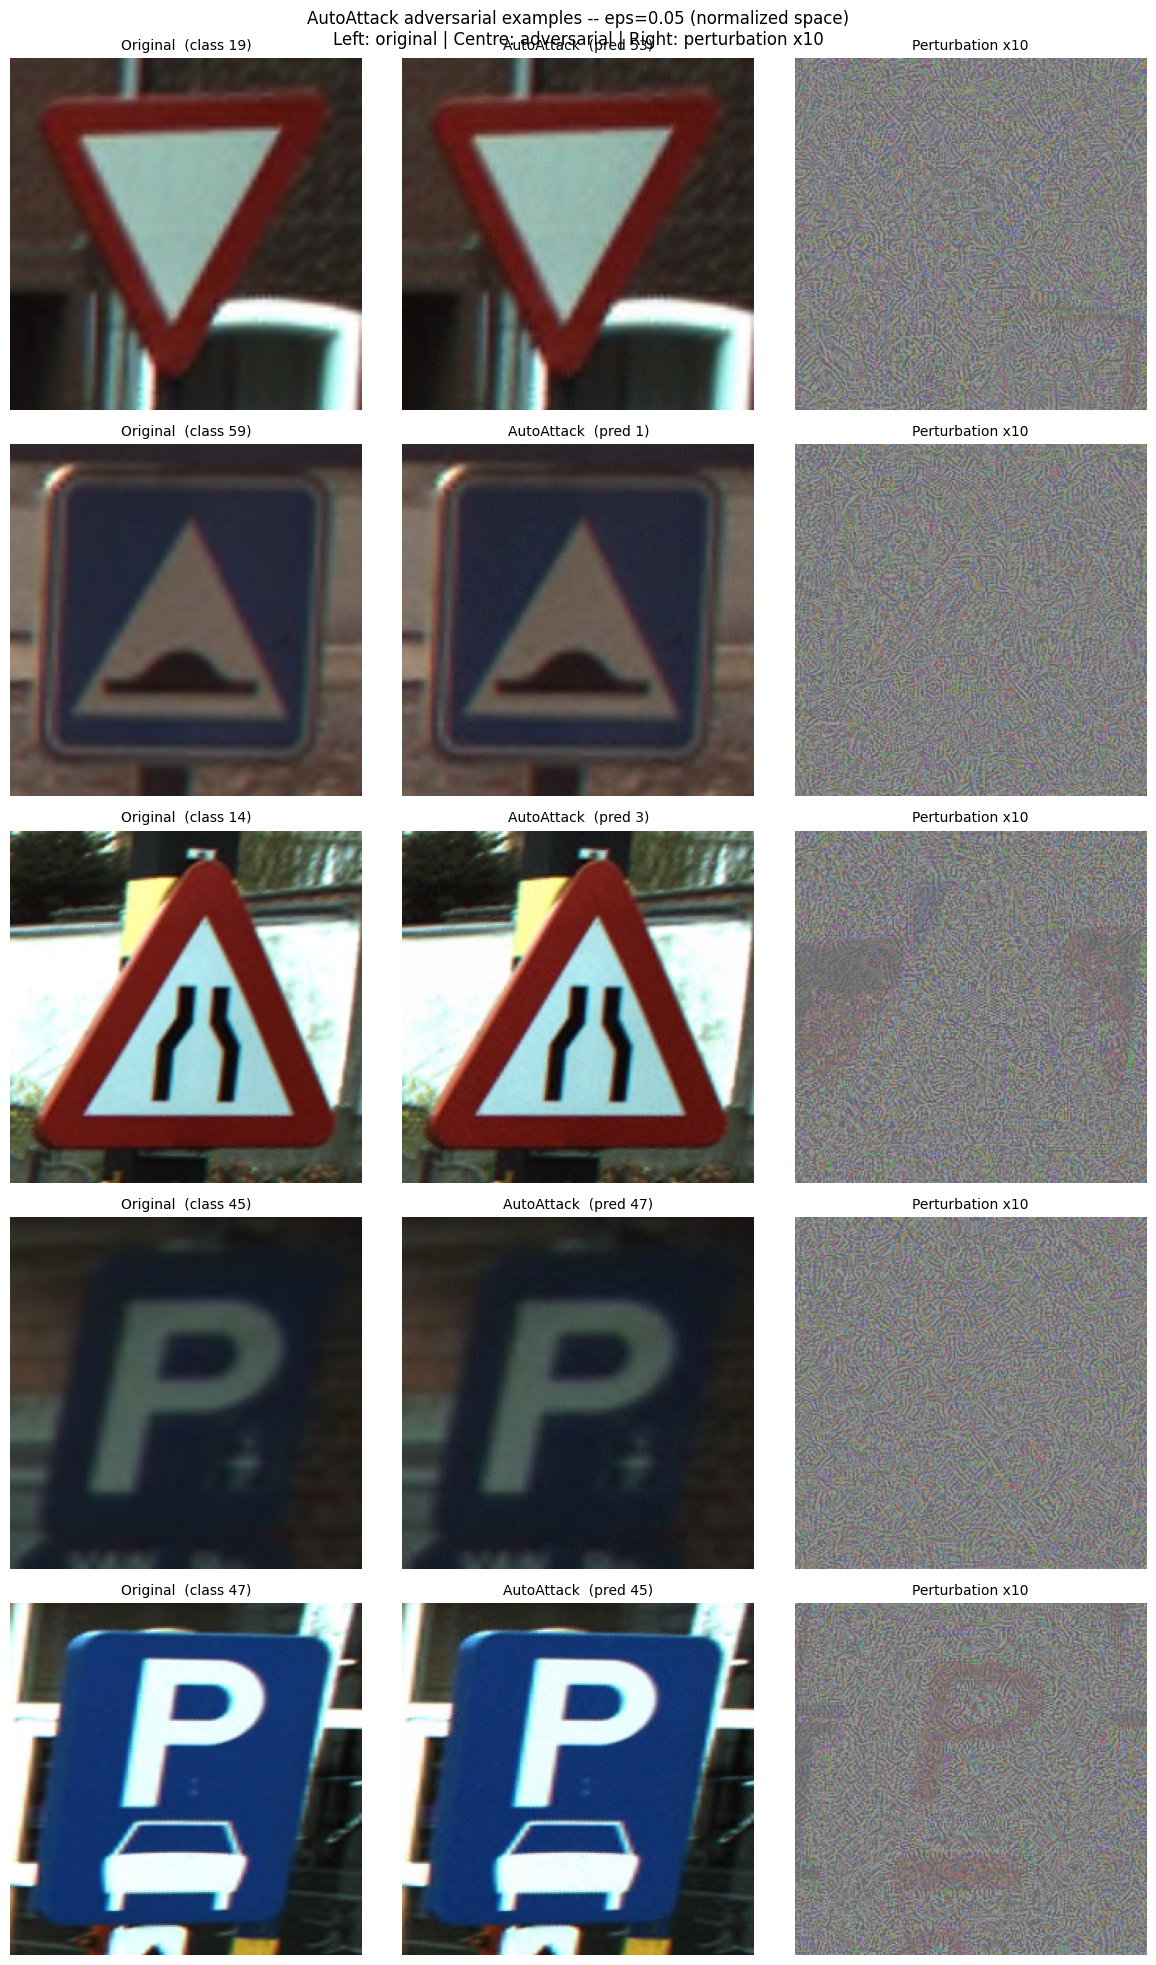

In [6]:
# Visualise adversarial examples at eps=0.05
VIS_EPS = 0.05
N_VIS   = 5

x_adv_vis = results[VIS_EPS]['x_adv'].to(device)

with torch.no_grad():
    clean_preds_v = wrapped_model(images).argmax(1).cpu()
    adv_preds_v   = wrapped_model(x_adv_vis).argmax(1).cpu()

labels_cpu = labels.cpu()
fooled_idx = [
    i for i in range(len(images))
    if clean_preds_v[i] == labels_cpu[i] and adv_preds_v[i] != labels_cpu[i]
]
vis_idx = fooled_idx[:N_VIS]
print(f'Visualising {len(vis_idx)} successfully-attacked images at eps={VIS_EPS}')

fig, axes = plt.subplots(max(len(vis_idx), 1), 3, figsize=(12, 4 * max(len(vis_idx), 1)))
if len(vis_idx) == 1:
    axes = axes[None, :]

for row, idx in enumerate(vis_idx):
    orig = images[idx].cpu()
    adv  = x_adv_vis[idx].cpu()
    diff = adv - orig

    axes[row, 0].imshow(orig.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[row, 0].set_title(f'Original  (class {labels_cpu[idx].item()})', fontsize=10)

    axes[row, 1].imshow(adv.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[row, 1].set_title(f'AutoAttack  (pred {adv_preds_v[idx].item()})', fontsize=10)

    diff_show = diff * 10 + 0.5
    axes[row, 2].imshow(diff_show.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[row, 2].set_title('Perturbation x10', fontsize=10)

    for ax in axes[row]:
        ax.axis('off')

plt.suptitle(
    f'AutoAttack adversarial examples -- eps={VIS_EPS} (normalized space)\n'
    f'Left: original | Centre: adversarial | Right: perturbation x10',
    fontsize=12
)
plt.tight_layout()
plt.show()


In [7]:
MODEL_NAME = 'MobileNetV3-Large'
DATASET    = 'BelgiumTSC'
PGD_ASR    = [99.95, 100.0, 100.0, 100.0]

max_gap = max(
    abs(results[e]['asr'] * 100 - pgd)
    for e, pgd in zip(EPS_NORMALIZED, PGD_ASR)
)
validates = max_gap < 1.0
partial   = max_gap < 5.0

print(f'{'=' * 62}')
print(f'  AutoAttack Summary')
print(f'{'=' * 62}')
print(f'  Model:   {MODEL_NAME}')
print(f'  Dataset: {DATASET}')
print()
print(f'  {"eps":>6} | {"Robust Acc":>11} | {"ASR":>9}')
print(f'  {"-"*35}')
for eps in EPS_NORMALIZED:
    r = results[eps]
    print(f'  {eps:>6.2f} | {r["robust_acc"]*100:>10.2f}% | {r["asr"]*100:>8.2f}%')
print()
print(f'  AutoAttack validates PGD: {"YES" if validates else "PARTIALLY" if partial else "NO"}')
print(f'  Max PGD-AutoAttack gap:   {max_gap:.2f} pp')
print()
if validates:
    conclusion = (
        f'AutoAttack confirms PGD results. PGD-20 with alpha=eps/4 was a '
        f'sufficiently strong attack; robust accuracy at eps=0.01 is '
        f'{results[0.01]["robust_acc"]*100:.1f}%.'
    )
elif partial:
    conclusion = (
        f'AutoAttack reveals a small gap from PGD ({max_gap:.1f} pp max), '
        f'suggesting PGD was slightly sub-optimal but the robustness picture is unchanged.'
    )
else:
    conclusion = (
        f'AutoAttack significantly outperforms PGD (gap up to {max_gap:.1f} pp). '
        f'The model has more robustness than PGD results suggested; '
        f'PGD hyperparameters should be reconsidered.'
    )
print(f'  Conclusion: {conclusion}')
print(f'{'=' * 62}')


  AutoAttack Summary
  Model:   MobileNetV3-Large
  Dataset: BelgiumTSC

     eps |  Robust Acc |       ASR
  -----------------------------------
    0.01 |       0.00% |   100.00%
    0.02 |       0.00% |   100.00%
    0.05 |       0.00% |   100.00%
    0.10 |       0.00% |   100.00%

  AutoAttack validates PGD: YES
  Max PGD-AutoAttack gap:   0.05 pp

  Conclusion: AutoAttack confirms PGD results. PGD-20 with alpha=eps/4 was a sufficiently strong attack; robust accuracy at eps=0.01 is 0.0%.
